Loading dataset...
Dataset shape: (1808122, 33)

First few rows:
        SrcAddr        DstAddr Proto  Sport  Dport State  sTos  dTos  \
0  31.96.153.11  147.32.84.229   tcp  60257    443   RST   0.0   0.0   
1  83.228.37.92  147.32.84.229   tcp   2571  13363   RST   0.0   0.0   
2  83.228.37.92  147.32.84.229   tcp   2574    443   RST   0.0   0.0   
3  83.228.37.92  147.32.84.229   tcp   2576     80   RST   0.0   0.0   
4  83.228.37.92  147.32.84.229   tcp   2571  13363   RST   0.0   0.0   

      SrcWin   DstWin  ...  SAppBytes  DAppBytes       Dur TotPkts  TotBytes  \
0  2097152.0  65535.0  ...          0          0  9.016532       7       508   
1    65535.0  65535.0  ...          0          0  2.903761       3       184   
2    65535.0  65535.0  ...          0          0  3.032142       3       184   
3    65535.0  65535.0  ...          0          0  2.932428       3       184   
4    65535.0  65535.0  ...          0          0  6.017523       3       184   

   TotAppByte      Ra

  Epoch 1/30 — reconstruction loss: 0.307889


  Epoch 2/30 — reconstruction loss: 0.115899


  Epoch 3/30 — reconstruction loss: 0.108367


  Epoch 4/30 — reconstruction loss: 0.059707


...

  Epoch 26/30 — reconstruction loss: 0.045543


  Epoch 27/30 — reconstruction loss: 0.023227


  Epoch 28/30 — reconstruction loss: 0.043641


  Epoch 29/30 — reconstruction loss: 0.048681


  Epoch 30/30 — reconstruction loss: 0.074673


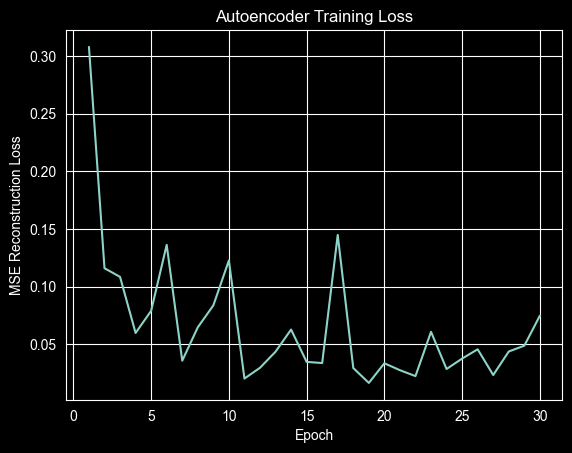


Tuning reconstruction-error threshold on training set...
Selected threshold        : 0.005036
Training FPR at threshold : 0.2070

  Autoencoder (reconstruction error threshold)

Classification Report:
              precision    recall  f1-score   support

  Non-Botnet       1.00      0.09      0.16    357877
      Botnet       0.01      0.99      0.02      3748

    accuracy                           0.10    361625
   macro avg       0.51      0.54      0.09    361625
weighted avg       0.99      0.10      0.16    361625

Confusion Matrix:
                Pred Non-Botnet  Pred Botnet
Act Non-Botnet           31,927      325,950
    Act Botnet               32        3,716

Accuracy : 0.0986

[Security Summary]
  Botnet Recall    : 0.9915  (target >= 0.85)
  Botnet Precision : 0.0113
  False Positive Rate (Non-Botnet flagged as Botnet): 0.9108  (target <= 0.05)


  FINAL SUMMARY — Test Set Performance
                     Botnet Recall  Botnet Precision  Botnet F1     FPR
Model        

In [3]:
# EE 467 Project: Botnet Traffic Detection
# Team Members: Aidan Frondozo, Jonah Grey, Logan Nguyen
#
# Goal: Binary classification of network flows as Botnet or Non-Botnet
# using the CTU-13 Dataset (Scenario 2).
#
# Pipeline overview:
#   1. Load & inspect data
#   2. Parse and encode labels (binary: Botnet vs Non-Botnet)
#   3. Feature engineering (timestamps, IPs, categoricals)
#   4. Chronological train/test split
#   5. Train models (Logistic Regression, Random Forest, Autoencoder)
#   6. Evaluate with botnet-recall-focused metrics

# ============================================================
# Dependencies
# ============================================================

import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm


# ============================================================
# Section 1: Load Data
# ============================================================

print("Loading dataset...")
zip_file = zipfile.ZipFile(r'dataset.zip')
zip_file.extractall(r'./')
df = pd.read_csv("dataset.csv")

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


# ============================================================
# Section 2: Label Parsing
# ============================================================
# Background and Legitimate traffic are both considered normal (Non-Botnet).
# We collapse all three original classes into a binary label:
#   0 = Non-Botnet (Background or Legitimate)
#   1 = Botnet

def parse_label(raw_label: str) -> int:
    """Map raw flow label string to binary class: 1=Botnet, 0=Non-Botnet."""
    if "botnet" in raw_label.lower():
        return 1
    return 0

print("\nParsing labels into binary classes (Botnet=1, Non-Botnet=0)...")
df["label_enc"] = df["Label"].apply(parse_label)

print("Class distribution (raw counts):")
print(df["label_enc"].value_counts().rename({0: "Non-Botnet", 1: "Botnet"}))
print("\nClass distribution (proportions):")
print(df["label_enc"].value_counts(normalize=True).rename({0: "Non-Botnet", 1: "Botnet"}).round(4))


# ============================================================
# Section 3: Feature Engineering
# ============================================================

# --- 3a. Timestamp features ---
# Use StartTime for chronological splitting; derive hour-of-day as a
# cyclical feature to capture time-of-day patterns without leaking ordering.

print("\nEngineering timestamp features...")
df["StartTime"] = pd.to_datetime(df["StartTime"])
df["LastTime"]  = pd.to_datetime(df["LastTime"])

df["hour_of_day"] = df["StartTime"].dt.hour
# Cyclical encoding so hour 23 and hour 0 are adjacent in feature space
df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

# Sortable integer timestamp used only for chronological splitting
df["start_ts"] = df["StartTime"].astype(np.int64)

# --- 3b. IP address features ---
# Raw IPs can trivially fingerprint specific hosts in this single-scenario
# dataset, causing leakage. We encode only the /24 subnet (first three
# octets) as an integer, preserving subnet structure without memorizing
# individual host identities.

def ip_to_subnet_int(ip_series: pd.Series) -> pd.Series:
    """Convert dotted-quad IPs to an integer representing the /24 subnet."""
    def _convert(ip):
        try:
            parts = str(ip).split(".")
            return (int(parts[0]) << 16) | (int(parts[1]) << 8) | int(parts[2])
        except Exception:
            return 0
    return ip_series.apply(_convert)

print("Encoding IP subnets...")
df["src_subnet"] = ip_to_subnet_int(df["SrcAddr"])
df["dst_subnet"] = ip_to_subnet_int(df["DstAddr"])

# --- 3c. Port features ---
# Raw port numbers are high-cardinality. We bucket them into three ranges:
# 0 = system (0-1023), 1 = registered (1024-49151), 2 = dynamic (49152+)

def port_bucket(port_series: pd.Series) -> pd.Series:
    """Bucket port numbers into 0=system, 1=registered, 2=dynamic."""
    def _bucket(p):
        try:
            p = int(p)
            if p <= 1023:
                return 0
            elif p <= 49151:
                return 1
            else:
                return 2
        except Exception:
            return -1
    return port_series.apply(_bucket)

print("Bucketing ports...")
df["sport_bucket"] = port_bucket(df["Sport"])
df["dport_bucket"] = port_bucket(df["Dport"])

# --- 3d. Categorical encoding ---
# Protocol and TCP state flags are low-cardinality; label-encode them.

print("Encoding categorical features...")
for col in ["Proto", "State"]:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))

# --- 3e. Assemble final feature matrix ---

NUMERIC_FEATURES = [
    "sTos", "dTos", "SrcWin", "DstWin", "sHops", "dHops",
    "sTtl", "dTtl", "TcpRtt", "SynAck", "AckDat",
    "SrcPkts", "DstPkts", "SrcBytes", "DstBytes",
    "SAppBytes", "DAppBytes", "Dur",
    "TotPkts", "TotBytes", "TotAppByte",
    "Rate", "SrcRate", "DstRate",
]
ENGINEERED_FEATURES = [
    "hour_sin", "hour_cos",
    "src_subnet", "dst_subnet",
    "sport_bucket", "dport_bucket",
    "Proto_enc", "State_enc",
]
ALL_FEATURES = NUMERIC_FEATURES + ENGINEERED_FEATURES

print(f"\nFinal feature count: {len(ALL_FEATURES)}")

# Fill any remaining NaNs with column median
df[ALL_FEATURES] = df[ALL_FEATURES].apply(pd.to_numeric, errors="coerce")
df[ALL_FEATURES] = df[ALL_FEATURES].fillna(df[ALL_FEATURES].median())

X = df[ALL_FEATURES].values
y = df["label_enc"].values


# ============================================================
# Section 4: Chronological Train / Test Split
# ============================================================
# We sort by StartTime and assign the earliest 80% to training.
# This ensures the model is always tested on future traffic it
# has not seen, which mirrors real deployment conditions and
# avoids temporal leakage.

print("\nPerforming chronological train/test split (80/20)...")
sorted_idx   = df["start_ts"].argsort().values
split_cutoff = int(len(sorted_idx) * 0.8)

train_idx = sorted_idx[:split_cutoff]
test_idx  = sorted_idx[split_cutoff:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train,      y_test     = y[train_idx], y[test_idx]

print(f"Training samples : {len(y_train):,}")
print(f"Test samples     : {len(y_test):,}")
print("\nTraining class distribution:")
for cls, name in [(0, "Non-Botnet"), (1, "Botnet")]:
    count = (y_train == cls).sum()
    print(f"  {name}: {count:,} ({count/len(y_train):.2%})")


# ============================================================
# Section 5: Scaling
# ============================================================
# CRITICAL: fit the scaler only on training data to prevent any
# test-set information from leaking into preprocessing.

print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)    # transform only, no fit


# ============================================================
# Section 6: Evaluation Helper
# ============================================================
# We care most about botnet recall (catching attacks) while keeping
# false positives low. This helper always reports both the full
# classification report and the security-focused summary.

def evaluate(model_name: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Print classification report, text confusion matrix, and security summary."""
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=["Non-Botnet", "Botnet"]))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(f"{'':>14} {'Pred Non-Botnet':>16} {'Pred Botnet':>12}")
    print(f"{'Act Non-Botnet':>14} {cm[0][0]:>16,} {cm[0][1]:>12,}")
    print(f"{'Act Botnet':>14} {cm[1][0]:>16,} {cm[1][1]:>12,}")

    print(f"\nAccuracy : {accuracy_score(y_true, y_pred):.4f}")

    botnet_recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    botnet_precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    non_botnet_mask  = (y_true == 0)
    fpr              = (y_pred[non_botnet_mask] == 1).mean()

    print(f"\n[Security Summary]")
    print(f"  Botnet Recall    : {botnet_recall:.4f}  (target >= 0.85)")
    print(f"  Botnet Precision : {botnet_precision:.4f}")
    print(f"  False Positive Rate (Non-Botnet flagged as Botnet): {fpr:.4f}  (target <= 0.05)")
    print(f"{'='*60}\n")


# ============================================================
# Section 7a: Baseline — Logistic Regression
# ============================================================
TVT_SPLIT_SEED = 31528476

print("Training Logistic Regression baseline...")
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # compensates for class imbalance
    random_state=TVT_SPLIT_SEED,
    solver="lbfgs",
)
model_lr.fit(X_train_scaled, y_train)
pred_lr = model_lr.predict(X_test_scaled)
evaluate("Logistic Regression", y_test, pred_lr)


# ============================================================
# Section 7b: Tree Ensemble — Random Forest
# ============================================================

print("Training Random Forest classifier...")
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced_subsample",
    random_state=TVT_SPLIT_SEED,
    n_jobs=-1,
)
model_rf.fit(X_train_scaled, y_train)
pred_rf = model_rf.predict(X_test_scaled)
evaluate("Random Forest", y_test, pred_rf)

# Top feature importances printed as a ranked text table
importances = model_rf.feature_importances_
feat_imp_df = (
    pd.DataFrame({"feature": ALL_FEATURES, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
feat_imp_df.index += 1   # rank from 1

print("Top 15 Feature Importances — Random Forest:")
print(feat_imp_df.to_string())


# ============================================================
# Section 7c: Anomaly / Representation — Autoencoder
# ============================================================
# The autoencoder is trained only on Non-Botnet traffic so it learns to
# reconstruct normal flows. Botnet flows, being anomalous, produce higher
# reconstruction error. We threshold that error to produce a binary
# prediction, tuning the threshold on the training set to achieve botnet
# recall >= 0.85 before evaluating on the held-out test set.

print("\nBuilding and training Autoencoder on Non-Botnet traffic only...")

# 1) Isolate non-botnet training samples for autoencoder training
X_ae_train = X_train_scaled[y_train == 0]

# 2) Convert to PyTorch tensors
X_ae_tensor   = torch.tensor(X_ae_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

ae_loader = DataLoader(TensorDataset(X_ae_tensor), batch_size=512, shuffle=True)

# 3) Define the autoencoder architecture
n_features = X_train_scaled.shape[1]

class BotnetAutoencoder(nn.Module):
    def __init__(self, n_in: int, latent_dim: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(),
            nn.Linear(64, n_in),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

torch_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {torch_device}")

ae_model   = BotnetAutoencoder(n_in=n_features, latent_dim=16).to(torch_device)
ae_optim   = torch.optim.AdamW(ae_model.parameters(), lr=1e-3)
ae_loss_fn = nn.MSELoss()

N_AE_EPOCHS = 30
ae_history  = []

print("Starting Autoencoder training...")
for epoch in range(N_AE_EPOCHS):
    ae_model.train()
    epoch_loss = 0.0
    for (batch,) in tqdm(ae_loader, desc=f"Epoch {epoch+1}/{N_AE_EPOCHS}", leave=False):
        batch = batch.to(torch_device)
        recon = ae_model(batch)
        loss  = ae_loss_fn(recon, batch)
        loss.backward()
        ae_optim.step()
        ae_optim.zero_grad()
        epoch_loss += loss.detach().cpu().item()

    avg_loss = epoch_loss / len(ae_loader)
    ae_history.append(avg_loss)
    print(f"  Epoch {epoch+1}/{N_AE_EPOCHS} — reconstruction loss: {avg_loss:.6f}")

# Plot training loss
xaxis = range(1, N_AE_EPOCHS + 1)
plt.plot(xaxis, ae_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.show()

# 4) Compute per-sample reconstruction error on the test set
ae_model.eval()
with torch.no_grad():
    X_test_recon = ae_model(X_test_tensor.to(torch_device)).cpu().numpy()

recon_errors_test = np.mean((X_test_scaled - X_test_recon) ** 2, axis=1)

# 5) Threshold tuning on the training set only.
#    Sweep candidate thresholds and select the one that achieves
#    botnet recall >= 0.85 at the lowest false positive rate.
print("\nTuning reconstruction-error threshold on training set...")

with torch.no_grad():
    X_train_recon = ae_model(
        torch.tensor(X_train_scaled, dtype=torch.float32).to(torch_device)
    ).cpu().numpy()
recon_errors_train = np.mean((X_train_scaled - X_train_recon) ** 2, axis=1)

thresholds  = np.percentile(recon_errors_train, np.arange(50, 100, 0.5))
best_thresh = thresholds[0]
best_fpr    = 1.0

for t in thresholds:
    pred_t   = (recon_errors_train > t).astype(int)
    recall_t = recall_score(y_train, pred_t, pos_label=1, zero_division=0)
    fpr_t    = pred_t[y_train == 0].mean()
    if recall_t >= 0.85 and fpr_t < best_fpr:
        best_fpr    = fpr_t
        best_thresh = t

print(f"Selected threshold        : {best_thresh:.6f}")
print(f"Training FPR at threshold : {best_fpr:.4f}")

# 6) Evaluate on the test set using the tuned threshold
pred_ae = (recon_errors_test > best_thresh).astype(int)
evaluate("Autoencoder (reconstruction error threshold)", y_test, pred_ae)


# ============================================================
# Section 8: Summary Comparison
# ============================================================

print("\n" + "="*60)
print("  FINAL SUMMARY — Test Set Performance")
print("="*60)

results = []
for name, preds in [
    ("Logistic Regression", pred_lr),
    ("Random Forest",       pred_rf),
    ("Autoencoder",         pred_ae),
]:
    br  = recall_score(y_test, preds, pos_label=1, zero_division=0)
    bp  = precision_score(y_test, preds, pos_label=1, zero_division=0)
    bf  = f1_score(y_test, preds, pos_label=1, zero_division=0)
    fpr = (preds[y_test == 0] == 1).mean()
    results.append({
        "Model":            name,
        "Botnet Recall":    round(br,  4),
        "Botnet Precision": round(bp,  4),
        "Botnet F1":        round(bf,  4),
        "FPR":              round(fpr, 4),
    })

summary_df = pd.DataFrame(results).set_index("Model")
print(summary_df.to_string())
print("\nTarget: Botnet Recall >= 0.85, FPR <= 0.05")